In [1]:
%matplotlib inline

import numpy as np
import pandas as pd

from tree_sne import TreeSNE

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_style('ticks')

from scipy.interpolate import splprep, splev
from mpl_toolkits.mplot3d import Axes3D

from sklearn.cluster import DBSCAN

from adjustText import adjust_text

# English vs American

In [2]:
meta = pd.read_pickle('hathi-data/lit-meta.pkl')
X = np.load('hathi-data/lit-model.npy')

Generate a tree-SNE embedding:

In [ ]:
treeSNE = TreeSNE(X, 2, 0.01, 50)
treeSNE.fit()
np.save('hathi-data/lit-fits.npy', treeSNE.fits)

Or load prefit embedding (and clustering):

In [ ]:
fits = np.load('hathi-data/lit-fits.npy')
#labellings = np.load('hathi-data/lit-clustering.npy')

Clustering the data at various levels:

In [ ]:
labellings = []
labels = []
counts = []

In [ ]:
for i in range(6):
    labelling = DBSCAN().fit(fits[i*10])
    l, c = np.unique(labelling, return_counts = True)
    labels.append(l)
    counts.append(c)

## Tracking A Cluster

In [8]:
n = labels[3][48]

In [9]:
counts[3][np.where(labels[3] == n)]

array([109])

In [10]:
np.unique(meta.iloc[np.where(labellings[3] == n)]['lc1'], return_counts=True)

(array(['PR', 'PS'], dtype=object), array([29, 80]))

In [11]:
au, co = np.unique(meta.iloc[np.where(labellings[3] == n)]['first_author_name'].astype('str'), return_counts=True)

for a, c in zip(au, co):
    #if c>1:
    print(f'{a}: {c}')

Abbott, Jacob, 1803-1879.: 1
Bierce, Ambrose, 1842-1914?: 4
Burroughs, John, 1837-1921.: 12
Fuller, Henry Blake, 1857-1929.: 3
Grange, Wallace B. (Wallace Byron), 1905-1987.: 1
Hassard, John R. G. (John Rose Greene), 1836-1888.: 1
Hawthorne, Nathaniel, 1804-1864.: 24
Hollingshead, John.: 1
Irving, Washington, 1783-1859.: 3
Muir, John, 1838-1914.: 9
Nicklin, J. A. (John Arnold): 2
Quillinan, Dorothy (Wordsworth), 1804-1847.: 3
Ruskin, John, 1819-1900.: 3
Shore, Emily, 1819-1839.: 1
Simmons, Jack, 1915-: 2
Smollett, T. (Tobias), 1721-1771.: 1
Southey, Robert, 1774-1843.: 1
Thoreau, Henry David, 1817-1862.: 23
Traill, Catherine Parr Strickland, 1802-1899.: 1
Wordsworth, Dorothy, 1771-1855.: 7
Wynter, Andrew, 1819-1876.: 6


In [12]:
clusts = np.unique(labellings[0][np.where(labellings[3] == n)])

for c in clusts:
    print(np.unique(meta.iloc[np.where((labellings[0] == c) & (labellings[3] == n))]['lc1'], return_counts=True))

(array(['PS'], dtype=object), array([11]))
(array(['PR'], dtype=object), array([1]))
(array(['PS'], dtype=object), array([11]))
(array(['PR', 'PS'], dtype=object), array([ 2, 13]))
(array(['PS'], dtype=object), array([13]))
(array(['PS'], dtype=object), array([4]))
(array(['PR', 'PS'], dtype=object), array([13, 18]))
(array(['PS'], dtype=object), array([7]))
(array(['PR', 'PS'], dtype=object), array([13,  3]))


In [ ]:
meta.iloc[np.where((labellings[0] == clusts[8]) & (labellings[3] == 47))]

,id,first_author_name,title,lc1,date,language,x,y
437156,hvd.hwpkl4,"Wordsworth, Dorothy, 1771-1855.",Journals of Dorothy Wordsworth /--- 2,PR,1897.0,English,17.912743,9.486387
777580,mdp.39015031304234,"Southey, Robert, 1774-1843.",Journal of a tour in the Netherlands in the au...,PR,1903.0,English,16.814182,9.806344
982418,mdp.39015063904083,"Quillinan, Dorothy (Wordsworth), 1804-1847.",Journal of a few months' residence in Portugal...,PR,1847.0,English,16.933365,9.652685
1243090,uc1.b3329002,"Nicklin, J. A. (John Arnold)","Dickens-land, described by J. A. Nicklin, pict...",PR,1911.0,English,18.249666,9.696583
1638578,hvd.hwpkl5,"Wordsworth, Dorothy, 1771-1855.",Journals of Dorothy Wordsworth /--- 2,PR,1897.0,English,17.894039,9.421888
2095216,nyp.33433081595336,"Quillinan, Dorothy (Wordsworth), 1804-1847.",Journal of a few months' residence in Portugal...,PR,1847.0,English,17.314959,9.569736
2342606,loc.ark:/13960/t9g458025,"Hassard, John R. G. (John Rose Greene), 1836-1...","A Pickwickian pilgrimage,",PR,1881.0,English,17.672842,9.404129
2747598,hvd.32044080816689,"Quillinan, Dorothy (Wordsworth), 1804-1847.",Journal of a few months' residence in Portugal...,PR,1847.0,English,16.667259,9.668076
2750464,mdp.39076005027136,"Wordsworth, Dorothy, 1771-1855.","Journals of Dorothy Wordsworth,--- v.1",PR,1941.0,English,18.507153,9.393338
4216707,uc1.b4007570,"Irving, Washington, 1783-1859.","Notes and journal of travel in Europe, 1804-18...",PS,1921.0,English,16.249208,9.449358


In [13]:
cols = ['#ED1C24', '#10769A']
colors = []
alphas = []
for i in range(100000):
    if labellings[3][i] == n:
        if meta.iloc[i]['lc1'] == 'PR':
            colors.append(cols[0])
            alphas.append(1)
        else:
            colors.append(cols[1])
            alphas.append(1)

In [20]:
cluster_fits = fits[:, np.where(labellings[3] == n)[0] ]

100%|██████████| 109/109 [00:01<00:00, 89.23it/s]


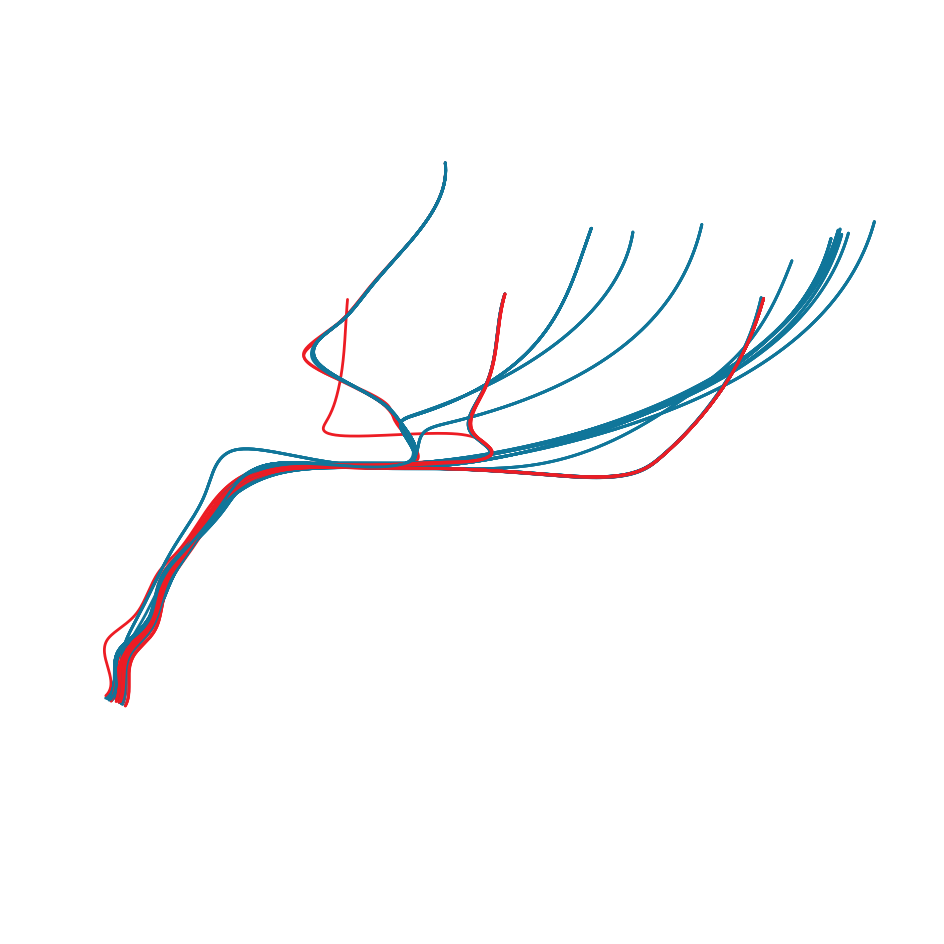

In [ ]:
stack_fits = np.zeros((51, cluster_fits.shape[1], 3))
for i in range(51):
    stack_fits[i] = np.column_stack((cluster_fits[i], i * np.ones(cluster_fits.shape[1])))

stack_x = stack_fits[:, :, 0].T
stack_y = stack_fits[:,:,1].T
stack_z = stack_fits[:,:,2].T
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')

for i in range(stack_fits.shape[1]):

# Fit a parametric spline to (x, y) over time
    points = [stack_x[i], stack_y[i], stack_z[i]]  # parametric curve in 3D

    tck, u = splprep(points, s=0.5)  # s is smoothing factor

    # Evaluate spline at finer resolution
    u_fine = np.linspace(0, 1, 500)
    x_smooth, y_smooth, t_smooth = splev(u_fine, tck)


    ax.plot(x_smooth, y_smooth, t_smooth, alpha=1, color=colors[i], linewidth=2)

ax.axis('off')

xlim = (stack_fits[:,:,0].min(), stack_fits[:,:,0].max())
ylim = (stack_fits[:,:,1].min(), stack_fits[:,:,1].max())
zlim = (stack_fits[:,:,2].min(), stack_fits[:,:,2].max())

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_zlim(zlim)

#ax.legend()
plt.show()

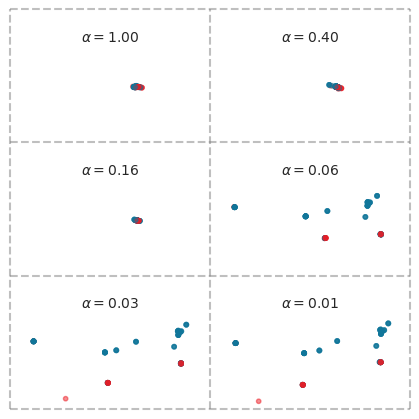

In [274]:
r = np.exp(np.log(0.01)/50)

fig = plt.figure(figsize=(4, 4))

cluster_fits_centered = cluster_fits - cluster_fits.mean(axis=1, keepdims=True)

t_margin = 0
b_margin = 0
r_margin = 0

xmax = np.max(cluster_fits_centered[:, :, 0])
xmin = np.min(cluster_fits_centered[:,:, 0])
ymax = np.max(cluster_fits_centered[:,:, 1])
ymin = np.min(cluster_fits_centered[:,:, 1])

xlim = (xmin-2, xmax+2)
ylim = (ymin-2, ymax+2)

m = 0.1

ncols, nrows = 2, 3
w, h = (1.0-r_margin) / ncols, (1.0-t_margin - b_margin) / nrows -m  # width and height of each subplot

for i in range(6):
    fit = cluster_fits_centered[i*10]

    col_idx = i % ncols
    row_idx = i // ncols

    left = col_idx * w
    bottom = (1-t_margin) - (row_idx+1) * (h + m)
    ax = fig.add_axes([left, bottom, w, h])

    ax.scatter(fit[:, 0], fit[:, 1], c=colors, s=10, alpha=0.5)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    #ax.set_aspect('equal', adjustable='box')
    ax.set_title(r'$\alpha = %.2f$' % (r**(i*10)), fontsize=10)
    ax.axis('off')

# handles = [mpatches.Patch(color=col[val], label=str(val)) for val in np.unique(y)]

fig.add_artist(plt.Line2D([0, 1-r_margin], [(1-t_margin+b_margin)/3, (1-t_margin+b_margin)/3], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 1-r_margin], [2*(1-t_margin+b_margin)/3, 2*(1-t_margin+b_margin)/3], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 1-r_margin], [(b_margin), (b_margin)], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 1-r_margin], [1,1], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 0], [b_margin,1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([1-r_margin, 1-r_margin], [b_margin,1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([(1-r_margin)/2, (1-r_margin)/2], [b_margin, 1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))
#fig.add_artist(plt.Line2D([2*(1-r_margin)/3, 2*(1-r_margin)/3], [b_margin, 1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))


## Full Visualization

In [ ]:
cols = ['#ED1C24', '#10769A'] #, '#BDBEC2']
colors = []
alphas = []
for i in range(100000):
    if meta.iloc[i]['lc1'] == 'PR':
        colors.append(cols[0])
        #alphas.append(1)
    else:
        colors.append(cols[1])
        #alphas.append(1)

100%|██████████| 100000/100000 [03:16<00:00, 507.73it/s]


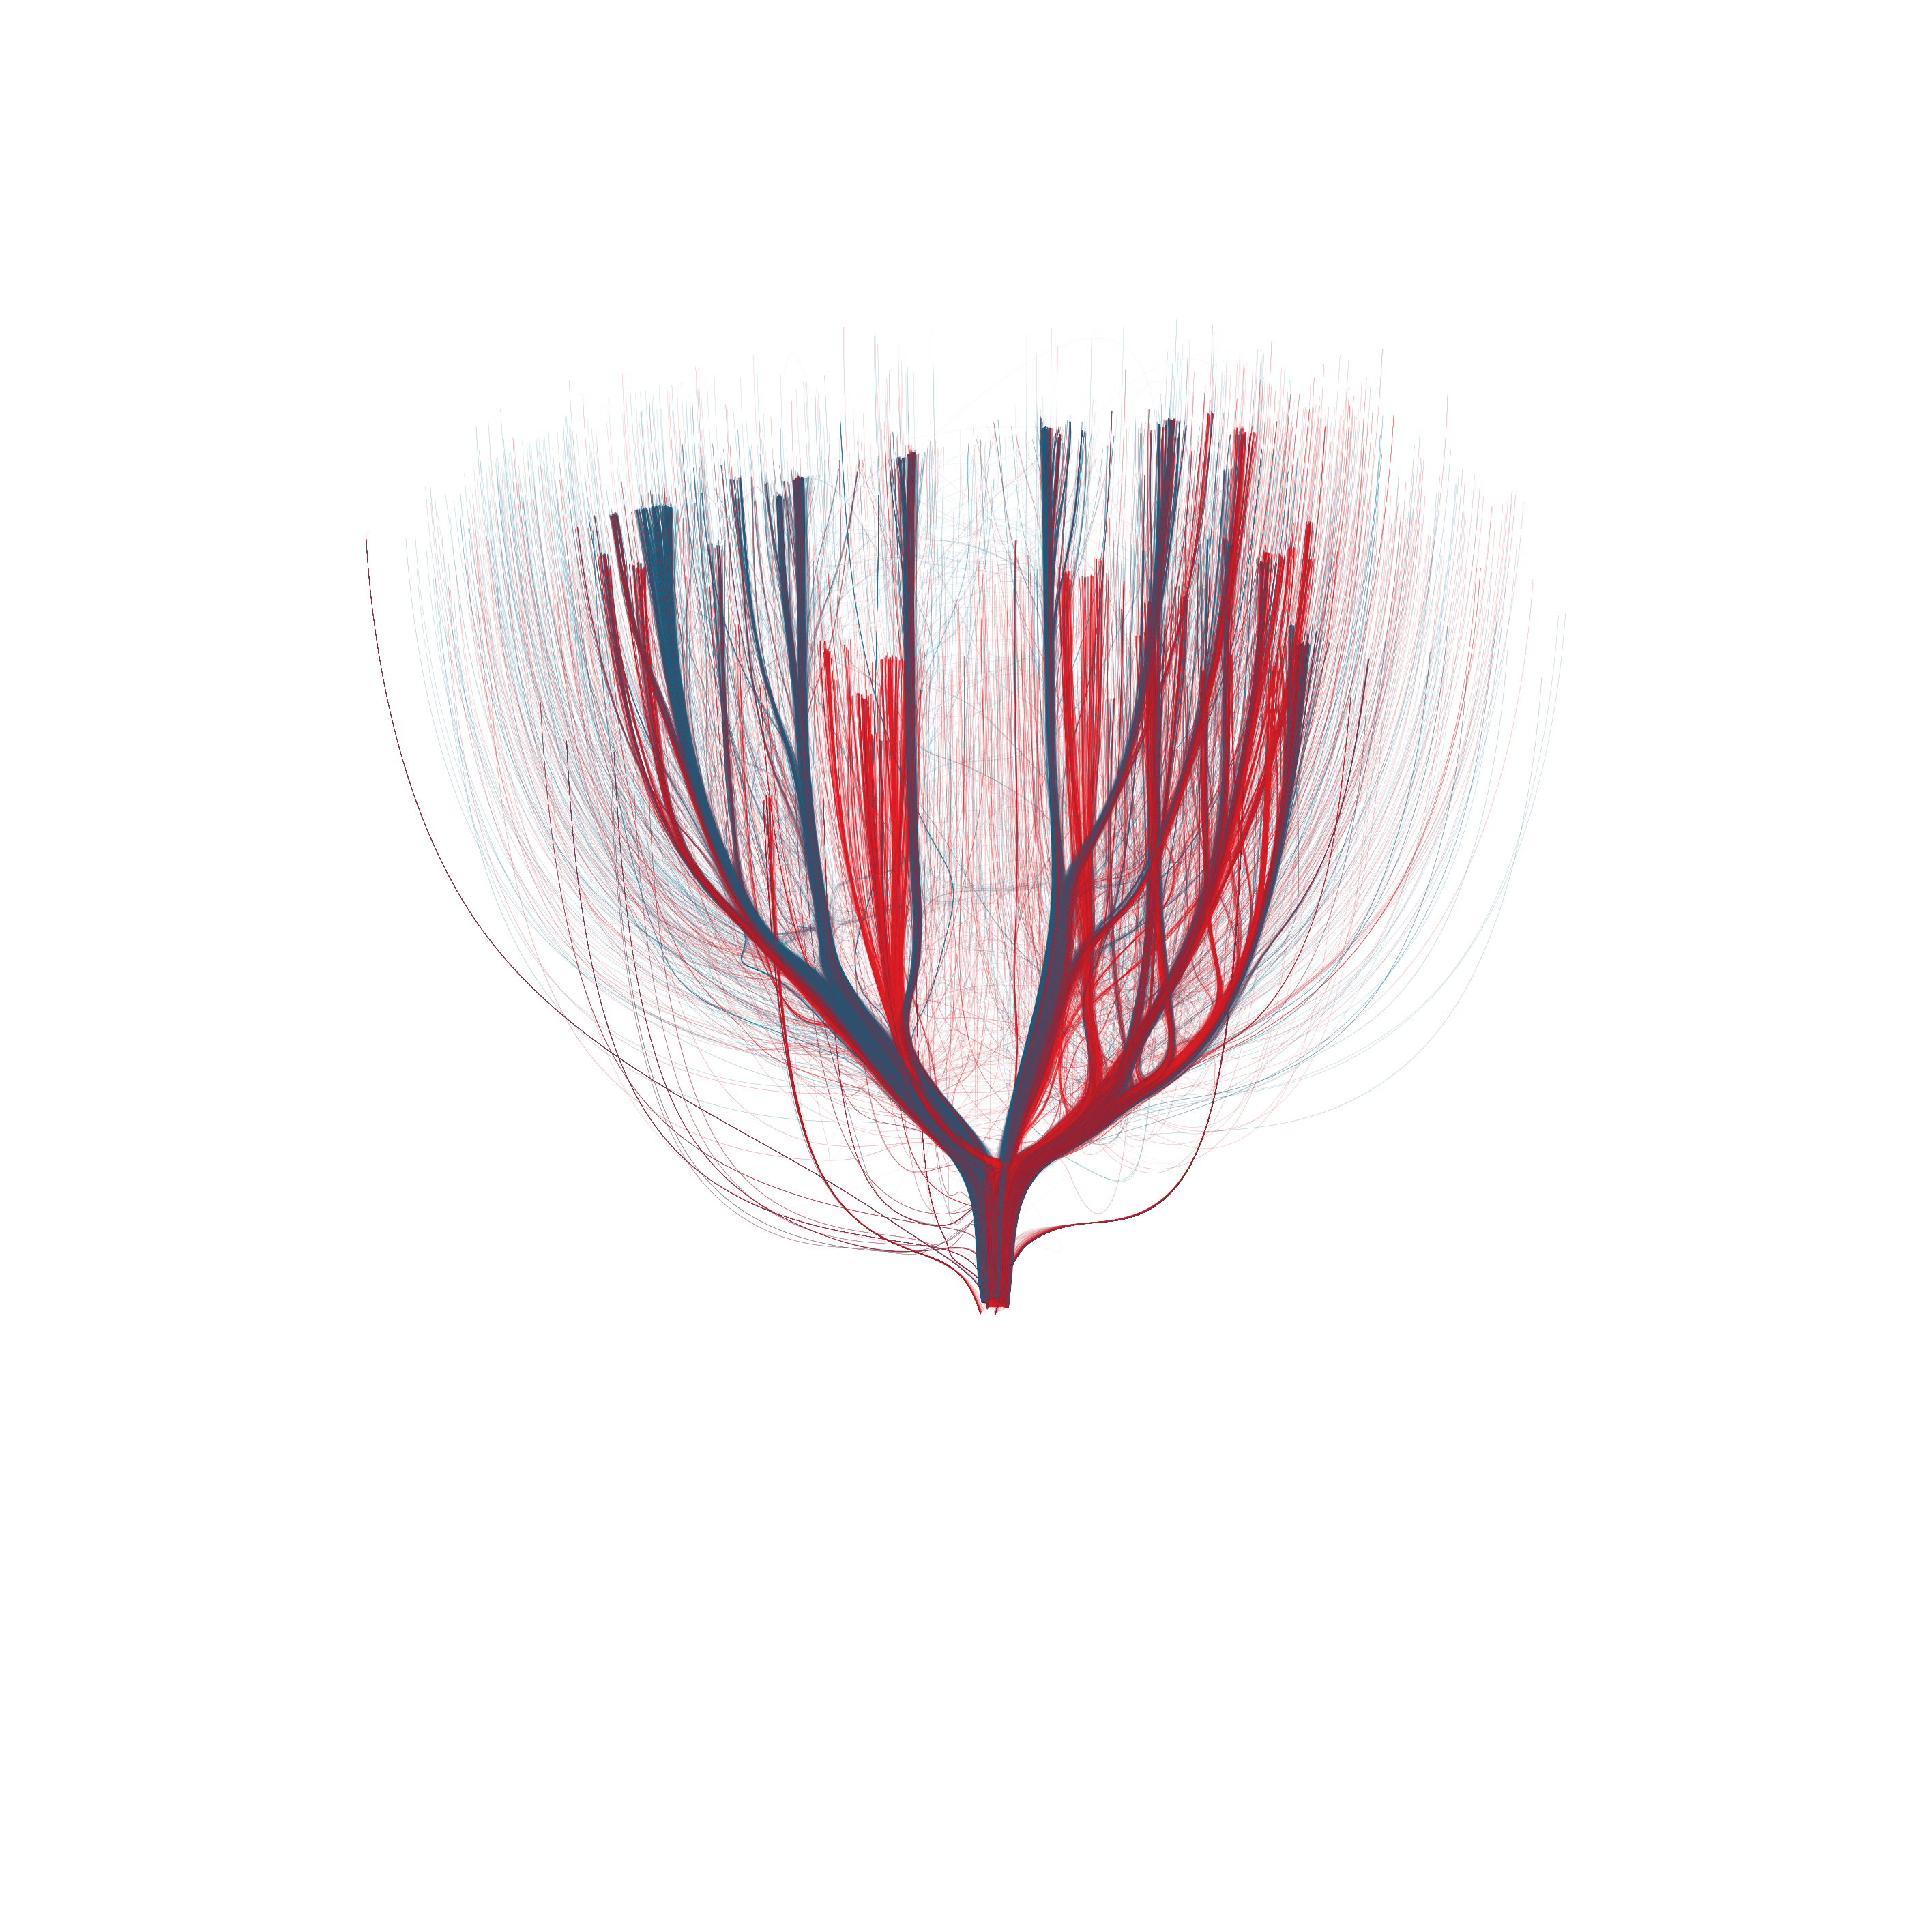

In [ ]:
stack_fits = np.zeros((51, fits.shape[1], 3))
for i in range(51):
    stack_fits[i] = np.column_stack((fits[i], i * np.ones(fits.shape[1])))

stack_x = stack_fits[:, :, 0].T
stack_y = stack_fits[:,:,1].T
stack_z = stack_fits[:,:,2].T
fig = plt.figure(figsize=(12,12), dpi=300)
ax = fig.add_subplot(projection='3d')

# for i in range(51):
#     ax.scatter(xs = stack_fits[i][:, 0], 
#                 ys=stack_fits[i][:, 1],  
#                 zs=stack_fits[i][:, 2], color=colors, 
#                 s=2, alpha=1)
    
for i in range(stack_fits.shape[1]):

# Fit a parametric spline to (x, y) over time
    points = [stack_x[i], stack_y[i], stack_z[i]]  # parametric curve in 3D

    tck, u = splprep(points, s=0.5)  # s is smoothing factor

    # Evaluate spline at finer resolution
    u_fine = np.linspace(0, 1, 100)
    x_smooth, y_smooth, t_smooth = splev(u_fine, tck)


    ax.plot(x_smooth, y_smooth, t_smooth, alpha=0.1, color=colors[i], linewidth=0.1)

ax.axis('off')

xlim = (stack_fits[:,:,0].min(), stack_fits[:,:,0].max())
ylim = (stack_fits[:,:,1].min(), stack_fits[:,:,1].max())
zlim = (stack_fits[:,:,2].min(), stack_fits[:,:,2].max())

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_zlim(zlim)

#ax.legend()
plt.show()

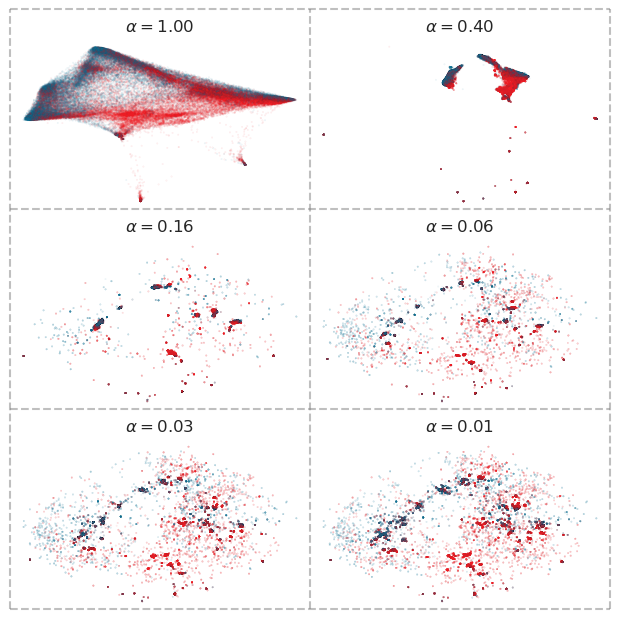

In [277]:
fig = plt.figure(figsize=(6, 6))

t_margin = 0
b_margin = 0
r_margin = 0

m = 0.05

ncols, nrows = 2, 3
w, h = (1.0-r_margin) / ncols, (1.0-t_margin - b_margin) / nrows -m  # width and height of each subplot

for i in range(6):
    fit = fits[i*10]

    col_idx = i % ncols
    row_idx = i // ncols

    left = col_idx * w
    bottom = (1-t_margin) - (row_idx+1) * (h + m)
    ax = fig.add_axes([left, bottom, w, h])

    ax.scatter(fit[:, 0], fit[:, 1], c=colors, s=0.1, alpha=0.1)
    ax.set_title(r'$\alpha = %.2f$' % (r**(i*10)))
    ax.axis('off')

# handles = [mpatches.Patch(color=col[val], label=str(val)) for val in np.unique(y)]

fig.add_artist(plt.Line2D([0, 1-r_margin], [(1-t_margin+b_margin)/3, (1-t_margin+b_margin)/3], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 1-r_margin], [2*(1-t_margin+b_margin)/3, 2*(1-t_margin+b_margin)/3], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 1-r_margin], [(b_margin), (b_margin)], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 1-r_margin], [1,1], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 0], [b_margin,1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([1-r_margin, 1-r_margin], [b_margin,1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([(1-r_margin)/2, (1-r_margin)/2], [b_margin, 1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))
#fig.add_artist(plt.Line2D([2*(1-r_margin)/3, 2*(1-r_margin)/3], [b_margin, 1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))

# fig.legend(handles=handles, loc="lower center", handlelength=3, title='Digit', ncols=10, frameon='False')

#plt.savefig('~/Documents/Research/tree-sne/overleaf/figures/PRPS-slices.png')

## Extra Cluster Analysis

In [ ]:
lang_labels = {}

for i in range(max(labels[4])+1):

    l, c = np.unique(meta[:100000].iloc[np.where(labellings[4] == i)]['language'], return_counts=True)
    if np.any(l != 'English'):
        if l[np.argmax(c)] != 'English':
            print(f'{i}: {l[np.argmax(c)]}, {np.max(c)}/{np.sum(c)}')
            lang_labels[i] = l[np.argmax(c)]

lang_labels[8] = 'Shakespeare'

non_english = []

cluster_labels = {}

for i in range(max(labels[0])):

    l, c = np.unique(meta[:100000].iloc[np.where(labellings[0] == i)]['language'], return_counts=True)
    if np.any(l != 'English'):
        if l[np.argmax(c)] != 'English':
            if l[np.argmax(c)] not in cluster_labels.values():
                cluster_labels[i] = l[np.argmax(c)]
                non_english.append(i)
                print(f'{i}: {l[np.argmax(c)]}, {np.max(c)}/{np.sum(c)}')

cluster_labels[20] = 'Shakespeare'
cluster_labels[108] = 'Austen'
cluster_labels[341] = 'Dickens'
cluster_labels[60] = 'Hawthorne'
cluster_labels[205] = 'Thoreau'
cluster_labels[342] = 'Emerson'
cluster_labels[164] = 'Poe'

2: Polish, 38/39
3: Russian, 100/103
4: French, 579/699
5: Dutch, 20/20
6: German, 1101/1169
7: Italian, 154/163
9: Spanish, 122/131
10: Japanese, 78/102
12: Portuguese, 17/17
13: Hebrew, 13/17
14: Chinese, 34/36
15: Swedish, 25/25
13: Polish, 38/39
14: Russian, 96/99
18: French, 579/711
44: Dutch, 20/20
47: German, 1071/1135
67: Italian, 150/163
112: Danish, 15/29
118: Spanish, 122/131
137: Japanese, 73/82
209: Portuguese, 16/16
234: Hebrew, 13/17
261: Czech, 6/9
321: Ukrainian, 5/13
464: Croatian, 4/7
591: Chinese, 34/36
647: Korean, 8/8
712: Swedish, 25/25
791: Hindi, 4/10


([Text(-16.406295579902775, -37.50467416193352, 'Polish'),
  Text(-21.384085511649687, -43.00511387677262, 'Russian'),
  Text(33.25917020022291, -27.288440451699035, 'French'),
  Text(1.5093242770248878, -46.76510232234106, 'Dutch'),
  Text(12.069650476343952, -49.49371023893781, 'German'),
  Text(23.71512448191757, -44.38144013883444, 'Italian'),
  Text(1.6621263153569146, -26.837680177486067, 'Danish'),
  Text(-47.45734891247021, -25.71537933727439, 'Spanish'),
  Text(-3.5292028341676485, -35.123482380831355, 'Japanese'),
  Text(23.194492804082927, -38.38954005795044, 'Portuguese'),
  Text(-9.161209557616473, -45.65617908788207, 'Hebrew'),
  Text(13.212176408705346, -24.813038179119182, 'Czech'),
  Text(10.84154666380141, -33.94423721749301, 'Ukrainian'),
  Text(26.912733962525664, -32.0265513104969, 'Croatian'),
  Text(-9.429565359635319, -51.844583290284596, 'Chinese'),
  Text(35.383146046932666, -42.96801293715986, 'Korean'),
  Text(-1.7855055636989334, -40.204868003758115, 'Swedi

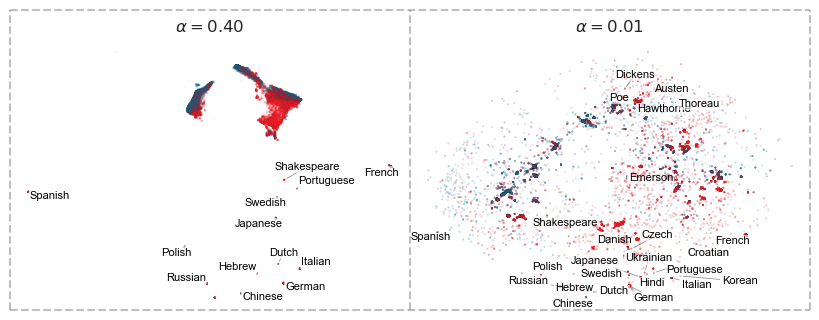

In [278]:
fig = plt.figure(figsize=(8, 3))

t_margin = 0
b_margin = 0
r_margin = 0

m = 0.1

ncols, nrows = 2, 1
w, h = (1.0-r_margin) / ncols, (1.0-t_margin - b_margin) / nrows -m  # width and height of each subplot

f = [fits[10], fits[50]]
a = [r**10, r**50]

axs = []

for i in range(2):
    fit = f[i]

    col_idx = i % ncols
    row_idx = i // ncols

    left = col_idx * w
    bottom = (1-t_margin) - (row_idx+1) * (h + m)
    ax = fig.add_axes([left, bottom, w, h])
    axs.append(ax)

    ax.scatter(fit[:, 0], fit[:, 1], c=colors, s=0.1, alpha=0.1)
    ax.set_title(r'$\alpha = %.2f$' % a[i])
    ax.axis('off')

fig.add_artist(plt.Line2D([0.5, 0.5], [(b_margin), 1-(t_margin)], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 0], [(b_margin), 1-(t_margin)], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([1, 1], [(b_margin), 1-(t_margin)], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 1], [1-t_margin, 1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 1], [b_margin, b_margin], linestyle='dashed', alpha=0.5, color='gray'))


# Annotating alpha = 0.40

l = labellings[4]
centers = []

for i in range(2, np.max(l)+ 1):        # Excluding clusters 0 and 1 since only interested in smaller clusters
    cluster = fits[10][np.where(l == i)]
    centers.append(np.mean(cluster, axis=0))

centers = np.array(centers)


texts = []
for i, (x, y) in enumerate(centers, start=2):
    if i!= 11:
        texts.append(
            axs[0].text(
                x, y, lang_labels[i],
                color='black',
                fontsize=8,
                ha='center', va='center',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1)
            )
        )

adjust_text(texts, ax=axs[0], arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

texts_2 = []
l = labellings[0]
centers_2 = []

for cluster in list(cluster_labels.keys()):
    centers_2.append(np.mean(fits[50][np.where(l==cluster)], axis=0))

for i, (x, y) in enumerate(centers_2):
    texts_2.append(
        axs[1].text(
            x, y, cluster_labels[list(cluster_labels.keys())[i]],
            color='black',
            fontsize=8,
            ha='center', va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1)
        )
    )

adjust_text(texts_2, ax=axs[1], arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))


# Shakespeare's Contemporaries

In [22]:
meta = pd.read_pickle('hathi-data/shakespeare-meta.pkl')
X = np.load('hathi-data/shakespeare-model.npy')

In [ ]:
treeSNE = TreeSNE(X, 2, 0.25, 10)
treeSNE.fit()
fits = treeSNE.fits
np.save('hathi-data/contemporaries-fits-25.npy')

In [23]:
fits = np.load('hathi-data/shakespeare-fits-25.npy')
fits.shape

(11, 2419, 2)

In [25]:
cols = ["#F2BB05",'#ED1C24', '#10769A', '#B9BDBA']
colors = []
alphas = []
sizes = []
for i in range(fits.shape[1]):
    if meta.iloc[i]['first_author_name'] == 'Shakespeare, William, 1564-1616':
        colors.append(cols[0])
        alphas.append(0.75)
        sizes.append(2)
    elif meta.iloc[i]['first_author_name'] == 'Marlowe, Christopher, 1564-1593.':
        colors.append(cols[1])
        alphas.append(0.75)
        sizes.append(2)
    elif meta.iloc[i]['first_author_name'] in ['Bacon, Francis, 1561-1626.',
    'Bacon, Francis, 1561-1626']:
        colors.append(cols[2])
        alphas.append(0.75)
        sizes.append(2)
    else:
        colors.append(cols[3])
        alphas.append(0.5)
        sizes.append(0.1)

slice_sizes = [s*2 for s in sizes]

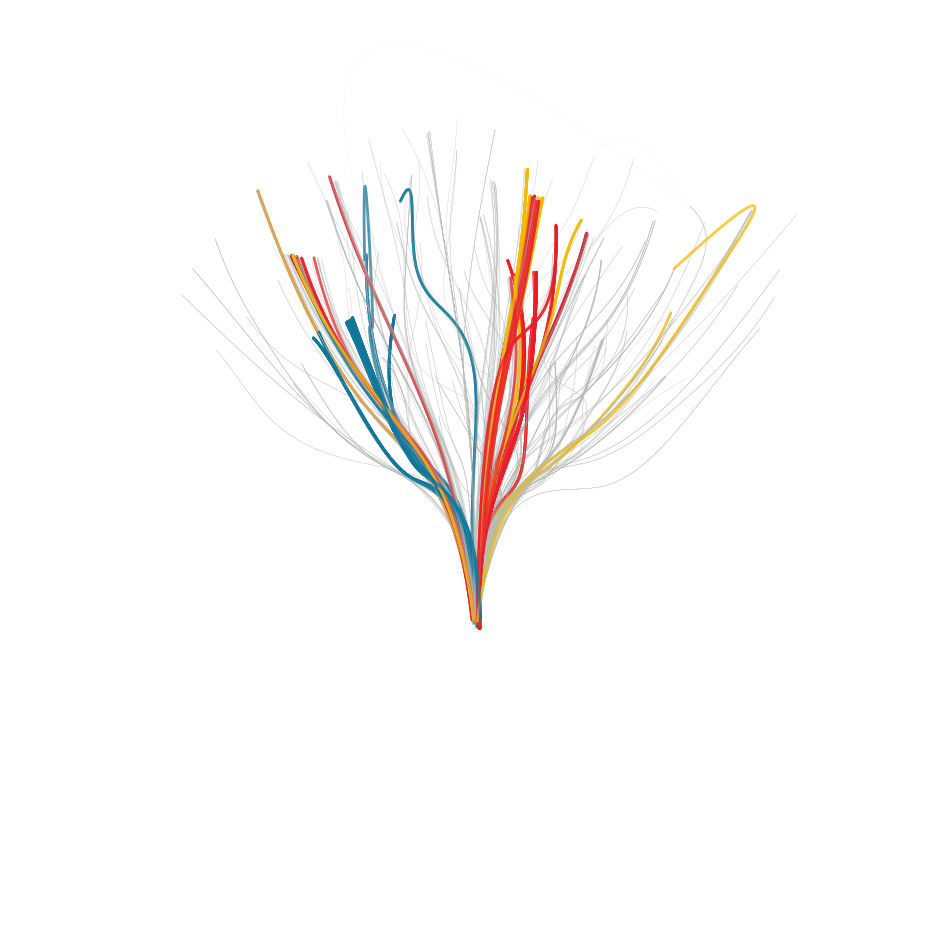

In [ ]:
stack_fits = np.zeros((fits.shape[0], fits.shape[1], 3))
for i in range(fits.shape[0]):
    stack_fits[i] = np.column_stack((fits[i], i * np.ones(fits.shape[1])))

stack_x = stack_fits[:, :, 0].T
stack_y = stack_fits[:,:,1].T
stack_z = stack_fits[:,:,2].T
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')

for i in range(stack_fits.shape[1]):

# Fit a parametric spline to (x, y) over time
    points = [stack_x[i], stack_y[i], stack_z[i]]  # parametric curve in 3D

    tck, u = splprep(points, s=0.5)  # s is smoothing factor

    # Evaluate spline at finer resolution
    u_fine = np.linspace(0, 1, 500)
    x_smooth, y_smooth, t_smooth = splev(u_fine, tck)


    ax.plot(x_smooth, y_smooth, t_smooth, alpha=alphas[i], color=colors[i], linewidth=sizes[i])

ax.axis('off')

xlim = (stack_fits[:,:,0].min(), stack_fits[:,:,0].max())
ylim = (stack_fits[:,:,1].min(), stack_fits[:,:,1].max())
zlim = (stack_fits[:,:,2].min(), stack_fits[:,:,2].max())

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_zlim(zlim)

#ax.legend()
plt.show()

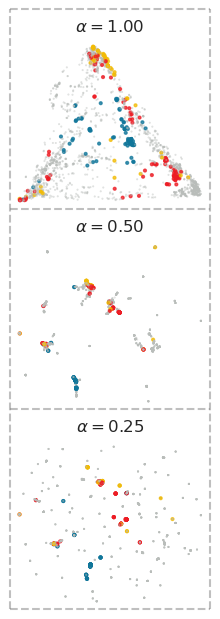

In [8]:
fig = plt.figure(figsize=(2, 6))

r = np.exp(np.log(0.25)/10)

t_margin = 0
b_margin = 0
r_margin = 0

m = 0.05

f = [0, 5, 10]

ncols, nrows = 1, 3
w, h = (1.0-r_margin) / ncols, (1.0-t_margin - b_margin) / nrows -m  # width and height of each subplot

for i in range(len(f)):
    fit = fits[f[i]]

    col_idx = i % ncols
    row_idx = i // ncols

    left = col_idx * w
    bottom = (1-t_margin) - (row_idx+1) * (h + m)
    ax = fig.add_axes([left, bottom, w, h])

    ax.scatter(fit[:, 0], fit[:, 1], c=colors, s=slice_sizes, alpha=alphas)
    ax.set_title(r'$\alpha = %.2f$' % (r**(f[i])))
    ax.axis('off')

fig.add_artist(plt.Line2D([0, 1-r_margin], [(b_margin), (b_margin)], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 1-r_margin], [1,1], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 0], [b_margin,1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([1-r_margin, 1-r_margin], [b_margin,1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 1],[1/3, 1/3], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([0, 1],[2/3, 2/3], linestyle='dashed', alpha=0.5, color='gray'))

## Cluster Analysis

In [195]:
labellings = np.load('hathi-data/contemporaries-clustering.npy')

In [27]:
labellings = []
labels = []
counts = []

In [ ]:
for i in range(11):
    labelling = DBSCAN().fit(fits[i])
    l, c = np.unique(labelling, return_counts = True)
    labels.append(l)
    counts.append(c)

In [ ]:
for i in range(np.max(labels[10])):
    au, co = np.unique(meta.iloc[np.where(labellings[10] == i)]['first_author_name'].astype('str'), return_counts = True)

    if np.any(au == 'Shakespeare, William, 1564-1616'):
        c=co[np.where(au == 'Shakespeare, William, 1564-1616')]
        print(i, c)

0 [38]
2 [7]
10 [1]
11 [7]
26 [2]
28 [3]
41 [1]
68 [3]
73 [1]


In [265]:
counts[10][np.where(labels[10] == 2)]

array([256])

In [ ]:
au, co = np.unique(meta.iloc[np.where(labellings[10] == 2)]['first_author_name'], return_counts=True)

for a, c in zip(au, co):
    print(a, c)

Bacon, Francis, 1561-1626 2
Bacon, Francis, 1561-1626. 4
Beaumont, Francis, 1584-1616. 21
Butler, Samuel, 1612-1680. 3
Chapman, George, 1559?-1634. 13
Daniel, Samuel, 1562-1619. 32
Dekker, Thomas, approximately 1572-1632. 11
Donne, John, 1572-1631. 9
Fletcher, John, 1579-1625. 7
Ford, John, 1586-ca. 1640. 4
Herbert, George, 1593-1633. 6
Heywood, Thomas, approximately 1574-1641. 23
Jonson, Ben, 1573?-1637. 13
Lyly, John, 1554?-1606. 5
Marlowe, Christopher, 1564-1593. 13
Massinger, Philip, 1583-1640. 6
Middleton, Thomas, d. 1627. 5
Nash, Thomas, 1567-1601. 19
Peele, George, 1556-1596. 11
Raleigh, Walter, Sir, 1552?-1618. 1
Shakespeare, William, 1564-1616 7
Shirley, James, 1596-1666. 1
Sidney, Philip, Sir, 1554-1586. 3
Spenser, Edmund, 1552?-1599. 13
Webster, John, 1580?-1625? 2
Wither, George, 1588-1667. 22
